# Purpose of Script

Perform exploratory analysis of electronic health records investigating relationships between cardiac events and flu cases.


### Pre-existing literature:

1. Effect of Influenza Vaccination on Major Cardiovascular Events and Mortality: A Systematic Review and Meta-Analysis of Randomized Controlled Trials ([September 2026](https://pubmed.ncbi.nlm.nih.gov/42720234/$0))
  * "Influenza vaccination significantly reduced major adverse cardiovascular events and cardiovascular mortality. A borderline reduction was observed for myocardial infarction and all-cause mortality. No significant differences were found for stroke, coronary revascularization, or heart failure-related hospitalization."


2. Influenza vaccination associates with reduced risk of incident ischemic stroke among older adults with diabetes: A population-based retrospective cohort study ([July 2026](https://pmc.ncbi.nlm.nih.gov/articles/PMC13432903/$0)).
  * "Seasonal influenza vaccination was associated with a significantly reduced risk of incident IS within 7 months among older adults with diabetes"


## Are influenza and cardiac events truly related? What other causes / variables may be playing a role?
* Diabetes
* Age
* Race / Ethnicity
* Location
* Gender
* Other prescribed medications

In [ ]:
## import statements
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

from google.colab.sql import bigquery as bq

# from IPython.display import clear_output

In [ ]:
cardiac_concept_codes = {
    'cerebro_accident': '230690007',
    'myocardial_infarction': '22298006'
                        }

flu_concept_codes = {
    'general_flu' : "6142004",
    'flu_virus' : "725894000",
    'flu_b' :  "24662006",
    'flu_a' :"442438000",
    'seasonal_flu' : "719590007",
    'pandemic_flu' : "719865001",
    'flu_c' : "81524006"
                    }

In [131]:
vaccine_concept_codes = {'flu_vaccine': "C178427",
                 'placeholder': '-1'}

In [ ]:
def cleanup_empty_columns(df: pd.DataFrame, column_list: list = []) -> pd.DataFrame:
  """

  """

  cols_to_drop = [
                'condition_start_datetime', 'condition_end_datetime', 'stop_reason',
                'visit_detail_id', 'condition_status_source_value', 'condition_status_concept_id',
                'provider_id_1', 'care_site_id', 'gender_source_concept_id',
                'ethnicity_source_concept_id', 'gender_concept_id', 'ethnicity_concept_id',
                "race_source_concept_id", "birth_datetime", 'gender_source_value',
                'race_source_value', 'ethnicity_source_value', 'person_source_value'
                  ]

  for col in cols_to_drop:
    # print(f'looking at col: {col}')
    if col in df.columns:
      # print(f'{col} in columns')

      # if df[col].isnull().sum() == len(df):
      df = df.drop(columns=[col])

  # print(df.columns)
  return df

In [ ]:
def get_total_cases(concept_codes_dict: dict, current_year: int = 2026) -> pd.DataFrame:
  """

  ;"""

  query = f"""
        WITH disease_subtypes AS
        ( SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
        WHERE 1 = 1
        -- take any diagnoses underneath the high level term
        AND `ancestor_concept_id` IN (
          SELECT `concept_id`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(concept_codes_dict.values())}
        )
        ),

        -- be very careful for duplicate information
        disease_happened as (
          SELECT *,
          EXTRACT(MONTH from `condition_start_date`) AS condition_start_date_month,
          EXTRACT(YEAR from `condition_start_date`) AS condition_start_date_year
          FROM disease_subtypes f
          LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence` co
          ON f.`descendant_concept_id` = co.`condition_concept_id`
        ),

        people_background as (

        SELECT *,
        `condition_start_date_year` - `year_of_birth` as `age_at_diagnosis`
        FROM disease_happened dh
        JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.person` p
        USING(`person_id`)
        ),

        gender_labeled as (
        select pb.*, con.`concept_name` as `gender_label`
        from people_background pb
        left join `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
        on pb.`gender_concept_id` = con.`concept_id`
        ),

        ethnicity_labeled as (
        select gl.*, con.`concept_name` as `ethnicity_label`
        from gender_labeled gl
        left join `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
        on gl.`ethnicity_concept_id` = con.`concept_id`
        ),

        diagnosis_labeled as (
        select el.*, con.`concept_name` as `condition_label`,

        from ethnicity_labeled el
        left join `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
        on el.`condition_concept_id` = con.`concept_id`
        )

        select *
        FROM diagnosis_labeled
        """

  disease_df = bq.run(query)

  print(f"Number of cases: {len(disease_df):,}")
  print(f"Number of unique people: {len(disease_df['person_id'].unique()):,}\n")

  display(disease_df.head())

  return disease_df

In [132]:
vaccine_df = get_total_cases(concept_codes_dict = vaccine_concept_codes)


Number of cases: 0


Number of unique people: 0



,person_id,ancestor_concept_id,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,condition_start_date,condition_start_datetime,condition_end_date,...,ethnicity_source_concept_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_datetime,age_at_diagnosis,gender_label,ethnicity_label,condition_label


In [ ]:
cardiac_df = get_total_cases(concept_codes_dict = cardiac_concept_codes)

cardiac_df = cleanup_empty_columns(cardiac_df)

Number of cases: 725,470


Number of unique people: 291,814



,person_id,ancestor_concept_id,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,condition_start_date,condition_start_datetime,condition_end_date,...,ethnicity_source_concept_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_datetime,age_at_diagnosis,gender_label,ethnicity_label,condition_label
0,157439,381316,380943,2,2,19582166,380943,2009-11-04,<NA>,2009-11-04,...,<NA>,8507,1932,3,1,<NA>,77,MALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm
1,1858604,381316,380943,2,2,230936088,380943,2010-05-05,<NA>,2010-05-05,...,<NA>,8507,1942,2,1,<NA>,68,MALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm
2,440184,381316,380943,2,2,54709089,380943,2009-06-26,<NA>,2009-06-26,...,<NA>,8507,1939,6,1,<NA>,70,MALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm
3,955731,381316,380943,2,2,118793239,380943,2010-02-23,<NA>,2010-02-23,...,<NA>,8507,1935,2,1,<NA>,75,MALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm
4,1545266,381316,380943,2,2,192018574,380943,2008-02-28,<NA>,2008-02-28,...,<NA>,8507,1943,7,1,<NA>,65,MALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm


In [ ]:
cardiac_df['ancestor_concept_id'].value_counts()

ancestor_concept_id
4329847    725396
381316         74
Name: count, dtype: Int64

In [ ]:
# same_date_dups = cardiac_df[cardiac_df.duplicated(subset=['person_id', 'condition_start_date'])].sort_values(by='person_id')

# same_date_dups

### Same Person, Same Visit - Multiple Diagnoses in the Same Tree Assigned

In [ ]:
person_seven = cardiac_df[cardiac_df['person_id'] == 7].sort_values(by='condition_start_date')
person_seven

,person_id,ancestor_concept_id,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,condition_start_date,condition_end_date,condition_type_concept_id,...,condition_start_date_year,race_concept_id,location_id,year_of_birth,month_of_birth,day_of_birth,age_at_diagnosis,gender_label,ethnicity_label,condition_label
0,7,4329847,441579,3,3,554,441579,2009-10-09,2009-10-10,38000230,...,2009,8527,7,1922,7,1,87,MALE,Not Hispanic or Latino,Acute myocardial infarction of inferoposterior...
1,7,4329847,444406,2,2,558,444406,2009-10-09,2009-10-10,38000230,...,2009,8527,7,1922,7,1,87,MALE,Not Hispanic or Latino,Acute subendocardial infarction
2,7,4329847,444406,2,2,557,444406,2009-10-09,2009-10-10,38000230,...,2009,8527,7,1922,7,1,87,MALE,Not Hispanic or Latino,Acute subendocardial infarction
3,7,4329847,434376,2,2,716,434376,2009-11-05,2009-11-05,38000230,...,2009,8527,7,1922,7,1,87,MALE,Not Hispanic or Latino,Acute myocardial infarction of anterior wall
4,7,4329847,438438,2,2,714,438438,2009-11-05,2009-11-05,38000230,...,2009,8527,7,1922,7,1,87,MALE,Not Hispanic or Latino,Acute myocardial infarction of anterolateral wall


In [ ]:
## by dedupping, we lose details on the different subtypes assigned - but could pivot to track as list in columns
cardiac_df_deduped = cardiac_df.drop_duplicates(subset=['person_id', 'condition_start_date', 'condition_end_date'])

### How many cardiac events per each person?

In [ ]:
cardiac_df_deduped['person_id'].value_counts()

person_id
1137719    23
724190     18
567353     17
1074555    17
1261391    17
21873      16
144000     15
306365     15
366478     15
812164     15
Name: count, dtype: Int64
...

[291814 rows]

In [ ]:
person_seven_clean = cardiac_df_deduped[cardiac_df_deduped['person_id'] == 7].sort_values(by='condition_start_date')
person_seven_clean

,person_id,ancestor_concept_id,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,condition_start_date,condition_end_date,condition_type_concept_id,...,condition_source_concept_id,condition_start_date_month,race_concept_id,location_id,year_of_birth,month_of_birth,day_of_birth,gender_label,ethnicity_label,condition_label
0,7,4329847,441579,3,3,554,441579,2009-10-09,2009-10-10,38000230,...,44820860,10,8527,7,1922,7,1,MALE,Not Hispanic or Latino,Acute myocardial infarction of inferoposterior...
1,7,4329847,438438,2,2,714,438438,2009-11-05,2009-11-05,38000230,...,44820858,11,8527,7,1922,7,1,MALE,Not Hispanic or Latino,Acute myocardial infarction of anterolateral wall


In [ ]:
flu_df = get_total_cases(concept_codes_dict = flu_concept_codes)

flu_df = cleanup_empty_columns(flu_df)

Number of cases: 40,091


Number of unique people: 25,093



,person_id,ancestor_concept_id,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,condition_start_date,condition_start_datetime,condition_end_date,...,ethnicity_source_concept_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_datetime,age_at_diagnosis,gender_label,ethnicity_label,condition_label
0,2277010,40483537,40484544,1,1,282990919,40484544,2010-11-28,<NA>,2010-11-28,...,<NA>,8507,1949,8,1,<NA>,61,MALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1
1,2277010,4266367,40484544,2,2,282990919,40484544,2010-11-28,<NA>,2010-11-28,...,<NA>,8507,1949,8,1,<NA>,61,MALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1
2,2277010,40483537,40484544,1,1,282990918,40484544,2010-11-28,<NA>,2010-11-28,...,<NA>,8507,1949,8,1,<NA>,61,MALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1
3,2277010,4266367,40484544,2,2,282990918,40484544,2010-11-28,<NA>,2010-11-28,...,<NA>,8507,1949,8,1,<NA>,61,MALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1
4,288010,40483537,40484544,1,1,35801943,40484544,2010-07-25,<NA>,2010-07-28,...,<NA>,8507,1911,11,1,<NA>,99,MALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1


In [ ]:
person_four_four_eight = flu_df[flu_df['person_id'] == 448]
## this has a duplicate as a result of a descent_id being linked to two ancestors
person_four_four_eight

,person_id,ancestor_concept_id,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,condition_start_date,condition_end_date,condition_type_concept_id,...,condition_start_date_year,race_concept_id,location_id,year_of_birth,month_of_birth,day_of_birth,age_at_diagnosis,gender_label,ethnicity_label,condition_label
0,448,4266367,314979,2,2,59197,314979,2008-03-23,2008-03-23,38000230,...,2008,8527,46,1932,4,1,76,FEMALE,Not Hispanic or Latino,Avian influenza
1,448,40483537,314979,1,1,59197,314979,2008-03-23,2008-03-23,38000230,...,2008,8527,46,1932,4,1,76,FEMALE,Not Hispanic or Latino,Avian influenza
2,448,4266367,256723,1,1,59198,256723,2008-03-23,2008-03-23,38000230,...,2008,8527,46,1932,4,1,76,FEMALE,Not Hispanic or Latino,Pneumonia and influenza


In [ ]:
flu_df_deduped = flu_df.drop_duplicates(subset=['person_id', 'condition_start_date', 'condition_end_date'])

In [ ]:
flu_counts = flu_df_deduped.value_counts('person_id').reset_index()
flu_counts = flu_counts.rename(columns={'count': 'flu_cases'})

if 'flu_cases' not in flu_df_deduped.columns:
  flu_df_deduped = flu_df_deduped.merge(flu_counts, how='outer', on = 'person_id')


assert (flu_df_deduped['flu_cases'] > 0).all(), 'Zero flu cases are found in the data'

In [ ]:
cardiac_counts = cardiac_df_deduped.value_counts('person_id').reset_index()
cardiac_counts = cardiac_counts.rename(columns={'count': 'cardiac_cases'})

if 'cardiac_counts' not in cardiac_df_deduped.columns:
  cardiac_df_deduped = cardiac_df_deduped.merge(cardiac_counts, how='outer', on = 'person_id')


assert (cardiac_df_deduped['cardiac_cases'] > 0).all(), 'Zero cardiac cases are found in the data'

## Diagnosed with Flu and Cardiac Event

In [ ]:
case_joined = flu_df_deduped.merge(cardiac_df_deduped, how='inner', on='person_id', suffixes=('_flu', '_cardiac'))

print(f"""Number of people who have had cardiac problems and the flu: {len(case_joined['person_id'].unique()):,}\n""")
case_joined.head()

Number of people who have had cardiac problems and the flu: 6,316



,person_id,ancestor_concept_id_flu,descendant_concept_id_flu,min_levels_of_separation_flu,max_levels_of_separation_flu,condition_occurrence_id_flu,condition_concept_id_flu,condition_start_date_flu,condition_end_date_flu,condition_type_concept_id_flu,...,race_concept_id_cardiac,location_id_cardiac,year_of_birth_cardiac,month_of_birth_cardiac,day_of_birth_cardiac,age_at_diagnosis_cardiac,gender_label_cardiac,ethnicity_label_cardiac,condition_label_cardiac,cardiac_cases
0,638331,4266367,314979,2,2,79326098,314979,2008-12-31,2008-12-31,38000230,...,8527,339,1925,1,1,83,FEMALE,Not Hispanic or Latino,Acute myocardial infarction,1
1,638331,4266367,256723,1,1,79326058,256723,2009-05-01,2009-05-07,38000230,...,8527,339,1925,1,1,83,FEMALE,Not Hispanic or Latino,Acute myocardial infarction,1
2,638331,4266367,256723,1,1,79326130,256723,2009-04-03,2009-04-03,38000230,...,8527,339,1925,1,1,83,FEMALE,Not Hispanic or Latino,Acute myocardial infarction,1
3,638331,4266367,314979,2,2,79326179,314979,2008-06-26,2008-06-26,38000230,...,8527,339,1925,1,1,83,FEMALE,Not Hispanic or Latino,Acute myocardial infarction,1
4,200150,4266367,314979,2,2,24885231,314979,2010-03-15,2010-03-16,38000230,...,8527,849,1938,12,1,71,FEMALE,Not Hispanic or Latino,Acute myocardial infarction,1


In [ ]:
def view_cross_conditions(df: pd.DataFrame, person_filter: int = None):


  if person_filter:
    df = df[df['person_id'] == person_filter]

  display(df[['person_id',
             'condition_start_date_flu', 'condition_end_date_flu', 'condition_label_flu', 'age_at_diagnosis_flu',
             'condition_start_date_cardiac', 'condition_end_date_cardiac', 'condition_label_cardiac', 'age_at_diagnosis_cardiac']])



In [ ]:
case_joined['flu_cardiac_time_delta'] = case_joined['condition_end_date_cardiac'] - case_joined['condition_end_date_flu']
case_joined['flu_cardiac_time_delta_int'] = pd.to_timedelta(case_joined['flu_cardiac_time_delta']).dt.days
case_joined

,person_id,ancestor_concept_id_flu,descendant_concept_id_flu,min_levels_of_separation_flu,max_levels_of_separation_flu,condition_occurrence_id_flu,condition_concept_id_flu,condition_start_date_flu,condition_end_date_flu,condition_type_concept_id_flu,...,location_id_cardiac,year_of_birth_cardiac,month_of_birth_cardiac,day_of_birth_cardiac,age_at_diagnosis_cardiac,gender_label_cardiac,ethnicity_label_cardiac,condition_label_cardiac,flu_cardiac_time_delta,flu_cardiac_time_delta_int
0,1164,4266367,256723,1,1,149536,256723,2008-07-20,2008-07-20,38000230,...,9,1940,4,1,69,FEMALE,Not Hispanic or Latino,Acute myocardial infarction,348 days 00:00:00,348
1,2400,4266367,256723,1,1,303497,256723,2008-03-04,2008-03-05,38000230,...,463,1932,8,1,76,FEMALE,Not Hispanic or Latino,Acute myocardial infarction,65 days 00:00:00,65
2,2464,4266367,314979,2,2,309635,314979,2009-06-23,2009-06-23,38000230,...,159,1917,10,1,91,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of anterolateral wall,-357 days +00:00:00,-357
3,2464,4266367,314979,2,2,309635,314979,2009-06-23,2009-06-23,38000230,...,159,1917,10,1,92,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of inferior wall,105 days 00:00:00,105
4,3374,4266367,314979,2,2,427243,314979,2008-05-15,2008-05-15,38000230,...,243,1929,1,1,80,MALE,Not Hispanic or Latino,Acute myocardial infarction,377 days 00:00:00,377
5,3374,4266367,314979,2,2,427243,314979,2008-05-15,2008-05-15,38000230,...,243,1929,1,1,80,MALE,Not Hispanic or Latino,Acute subendocardial infarction,563 days 00:00:00,563
6,3395,4266367,256723,1,1,429987,256723,2009-06-27,2009-07-06,38000230,...,205,1933,1,1,75,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of inferior wall,-475 days +00:00:00,-475
7,3534,40483537,314979,1,1,449513,314979,2009-04-19,2009-04-19,38000230,...,404,1928,6,1,80,MALE,Not Hispanic or Latino,Acute myocardial infarction,-258 days +00:00:00,-258
8,3800,40483537,314979,1,1,483462,314979,2010-04-13,2010-04-13,38000230,...,37,1919,3,1,90,MALE,Not Hispanic or Latino,Acute myocardial infarction,-222 days +00:00:00,-222
9,3872,4266367,256723,1,1,494687,256723,2008-01-12,2008-01-12,38000230,...,54,1936,7,1,74,FEMALE,Not Hispanic or Latino,Acute subendocardial infarction,975 days 00:00:00,975


In [ ]:
ethnicity_focus = flu_df_deduped[flu_df_deduped['']]

In [ ]:
flu_df_deduped

,person_id,ancestor_concept_id,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,condition_start_date,condition_end_date,condition_type_concept_id,...,race_concept_id,location_id,year_of_birth,month_of_birth,day_of_birth,age_at_diagnosis,gender_label,ethnicity_label,condition_label,flu_cases
0,638331,40483537,314979,1,1,79326179,314979,2008-06-26,2008-06-26,38000230,...,8527,339,1925,1,1,83,FEMALE,Not Hispanic or Latino,Avian influenza,4
1,638331,4266367,256723,1,1,79326061,256723,2009-05-01,2009-05-07,38000230,...,8527,339,1925,1,1,84,FEMALE,Not Hispanic or Latino,Pneumonia and influenza,4
2,638331,4266367,256723,1,1,79326130,256723,2009-04-03,2009-04-03,38000230,...,8527,339,1925,1,1,84,FEMALE,Not Hispanic or Latino,Pneumonia and influenza,4
3,638331,40483537,314979,1,1,79326098,314979,2008-12-31,2008-12-31,38000230,...,8527,339,1925,1,1,83,FEMALE,Not Hispanic or Latino,Avian influenza,4
4,200150,4266367,256723,1,1,24885204,256723,2010-03-25,2010-03-25,38000230,...,8527,849,1938,12,1,72,FEMALE,Not Hispanic or Latino,Pneumonia and influenza,3
5,200150,4266367,314979,2,2,24885231,314979,2010-03-15,2010-03-16,38000230,...,8527,849,1938,12,1,72,FEMALE,Not Hispanic or Latino,Avian influenza,3
6,200150,4266367,320752,1,1,24885229,320752,2008-05-28,2008-05-28,38000230,...,8527,849,1938,12,1,70,FEMALE,Not Hispanic or Latino,Influenza with non-respiratory manifestation,3
7,218078,4266367,256723,1,1,27110964,256723,2009-05-23,2009-05-23,38000230,...,8516,473,1935,12,1,74,FEMALE,Not Hispanic or Latino,Pneumonia and influenza,3
8,218078,4266367,256723,1,1,27111064,256723,2009-07-10,2009-07-10,38000230,...,8516,473,1935,12,1,74,FEMALE,Not Hispanic or Latino,Pneumonia and influenza,3
9,218078,4266367,320752,1,1,27111019,320752,2009-05-11,2009-05-11,38000230,...,8516,473,1935,12,1,74,FEMALE,Not Hispanic or Latino,Influenza with non-respiratory manifestation,3


In [ ]:
view_cross_conditions(case_joined, 23742)

,person_id,condition_start_date_flu,condition_end_date_flu,condition_label_flu,age_at_diagnosis_flu,condition_start_date_cardiac,condition_end_date_cardiac,condition_label_cardiac,age_at_diagnosis_cardiac
0,23742,2010-01-02,2010-01-02,Pneumonia and influenza,46,2008-04-15,2008-05-20,Acute subendocardial infarction,44
1,23742,2010-01-02,2010-01-02,Pneumonia and influenza,46,2008-08-26,2008-08-26,Acute myocardial infarction,44
2,23742,2010-01-02,2010-01-02,Pneumonia and influenza,46,2008-09-29,2008-09-29,Acute myocardial infarction of inferior wall,44
3,23742,2010-01-02,2010-01-02,Pneumonia and influenza,46,2009-04-29,2009-04-29,Acute subendocardial infarction,45
4,23742,2010-01-02,2010-01-02,Pneumonia and influenza,46,2009-05-12,2009-05-12,Acute myocardial infarction,45
5,23742,2010-01-02,2010-01-02,Pneumonia and influenza,46,2009-09-23,2009-09-23,Acute myocardial infarction,45


In [ ]:
closest_distance = case_joined[case_joined['flu_cardiac_time_delta_int'] >= 0]
closest_distance = closest_distance.sort_values(by=['flu_cardiac_time_delta_int']).drop_duplicates(subset='person_id')
closest_distance

,person_id,ancestor_concept_id_flu,descendant_concept_id_flu,min_levels_of_separation_flu,max_levels_of_separation_flu,condition_occurrence_id_flu,condition_concept_id_flu,condition_start_date_flu,condition_end_date_flu,condition_type_concept_id_flu,...,location_id_cardiac,year_of_birth_cardiac,month_of_birth_cardiac,day_of_birth_cardiac,age_at_diagnosis_cardiac,gender_label_cardiac,ethnicity_label_cardiac,condition_label_cardiac,flu_cardiac_time_delta,flu_cardiac_time_delta_int
0,1769788,4266367,256723,1,1,219923634,256723,2009-06-30,2009-07-11,38000200,...,616,1927,7,1,82,MALE,Not Hispanic or Latino,Acute subendocardial infarction,0 days 00:00:00,0
1,827381,4266367,256723,1,1,102847006,256723,2008-03-02,2008-03-02,38000230,...,82,1969,6,1,39,MALE,Not Hispanic or Latino,Acute myocardial infarction of inferolateral wall,0 days 00:00:00,0
2,285134,4266367,256723,1,1,35448026,256723,2008-10-12,2008-10-13,38000200,...,39,1943,4,1,65,MALE,Not Hispanic or Latino,Acute subendocardial infarction,0 days 00:00:00,0
3,1101659,4266367,256723,1,1,136845538,256723,2009-12-18,2009-12-23,38000230,...,817,1943,6,1,66,MALE,Not Hispanic or Latino,Acute subendocardial infarction,0 days 00:00:00,0
4,953290,4266367,320752,1,1,118488237,320752,2010-06-25,2010-06-25,38000230,...,2092,1919,5,1,91,FEMALE,Not Hispanic or Latino,Acute subendocardial infarction,0 days 00:00:00,0
5,1597579,4266367,256723,1,1,198536606,256723,2009-06-29,2009-07-05,38000200,...,62,1920,10,1,89,FEMALE,Not Hispanic or Latino,Acute subendocardial infarction,0 days 00:00:00,0
6,5215,4266367,256723,1,1,666914,256723,2008-03-29,2008-03-30,38000200,...,440,1918,8,1,90,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of anterior wall,0 days 00:00:00,0
7,2023430,4266367,256723,1,1,251446675,256723,2008-11-24,2008-11-24,38000230,...,46,1925,4,1,83,MALE,Not Hispanic or Latino,Acute myocardial infarction,0 days 00:00:00,0
8,2109955,4266367,256723,1,1,262190379,256723,2009-11-09,2009-11-10,38000230,...,364,1927,1,1,82,FEMALE,Not Hispanic or Latino,Acute subendocardial infarction,0 days 00:00:00,0
9,1333298,4266367,314979,2,2,165671299,314979,2010-01-29,2010-01-29,38000230,...,941,1973,1,1,37,MALE,Not Hispanic or Latino,Acute subendocardial infarction,0 days 00:00:00,0


In [ ]:
view_cross_conditions(closest_distance)

,person_id,condition_start_date_flu,condition_end_date_flu,condition_label_flu,age_at_diagnosis_flu,condition_start_date_cardiac,condition_end_date_cardiac,condition_label_cardiac,age_at_diagnosis_cardiac
0,1769788,2009-06-30,2009-07-11,Pneumonia and influenza,82,2009-06-30,2009-07-11,Acute subendocardial infarction,82
1,827381,2008-03-02,2008-03-02,Pneumonia and influenza,39,2008-03-02,2008-03-02,Acute myocardial infarction of inferolateral wall,39
2,285134,2008-10-12,2008-10-13,Pneumonia and influenza,65,2008-10-12,2008-10-13,Acute subendocardial infarction,65
3,1101659,2009-12-18,2009-12-23,Pneumonia and influenza,66,2009-12-18,2009-12-23,Acute subendocardial infarction,66
4,953290,2010-06-25,2010-06-25,Influenza with non-respiratory manifestation,91,2010-06-25,2010-06-25,Acute subendocardial infarction,91
5,1597579,2009-06-29,2009-07-05,Pneumonia and influenza,89,2009-06-29,2009-07-05,Acute subendocardial infarction,89
6,5215,2008-03-29,2008-03-30,Pneumonia and influenza,90,2008-03-29,2008-03-30,Acute myocardial infarction of anterior wall,90
7,2023430,2008-11-24,2008-11-24,Pneumonia and influenza,83,2008-11-24,2008-11-24,Acute myocardial infarction,83
8,2109955,2009-11-09,2009-11-10,Pneumonia and influenza,82,2009-11-09,2009-11-10,Acute subendocardial infarction,82
9,1333298,2010-01-29,2010-01-29,Avian influenza,37,2010-01-29,2010-01-29,Acute subendocardial infarction,37


In [ ]:
case_joined[case_joined['person_id'] ==  2464]

,person_id,ancestor_concept_id_flu,descendant_concept_id_flu,min_levels_of_separation_flu,max_levels_of_separation_flu,condition_occurrence_id_flu,condition_concept_id_flu,condition_start_date_flu,condition_end_date_flu,condition_type_concept_id_flu,...,condition_start_date_year_cardiac,race_concept_id_cardiac,location_id_cardiac,year_of_birth_cardiac,month_of_birth_cardiac,day_of_birth_cardiac,age_at_diagnosis_cardiac,gender_label_cardiac,ethnicity_label_cardiac,condition_label_cardiac
0,2464,4266367,314979,2,2,309635,314979,2009-06-23,2009-06-23,38000230,...,2008,8527,159,1917,10,1,91,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of anterolateral wall
1,2464,4266367,314979,2,2,309635,314979,2009-06-23,2009-06-23,38000230,...,2009,8527,159,1917,10,1,92,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of inferior wall


Text(0.5, 0, 'Days Between Flu and Cardiac Event')

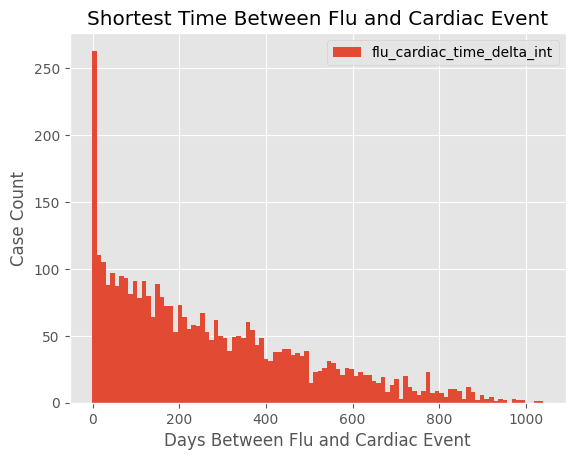

In [ ]:
closest_distance['flu_cardiac_time_delta_int'].hist(bins=100)

plt.title("Shortest Time Between Flu and Cardiac Event")
plt.ylabel("Case Count")
plt.xlabel("Days Between Flu and Cardiac Event")

In [ ]:
case_joined['cardiac_cases'].max()

np.int64(12)

In [ ]:
import seaborn as sns

Text(0.5, 1.0, 'Number of Cardiac Events Related to Number of Flu Cases')

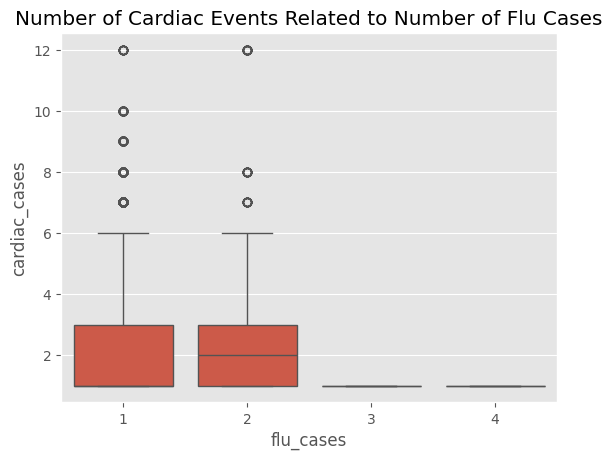

In [ ]:
sns.boxplot(data = case_joined[['flu_cases', 'cardiac_cases']],
            x = 'flu_cases',
            y='cardiac_cases')

plt.title("Number of Cardiac Events Related to Number of Flu Cases")

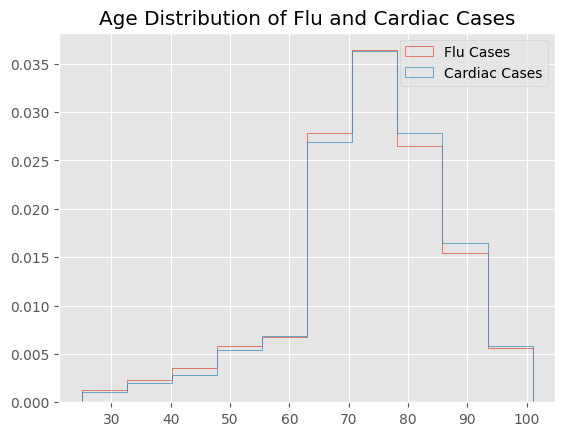

In [ ]:
plt.hist(flu_df_deduped['age_at_diagnosis'], density=True, histtype='step', label='Flu Cases')
plt.hist(cardiac_df_deduped['age_at_diagnosis'], density=True, histtype='step', label='Cardiac Cases')

## need to address the join complexity of this section and the ages when crossed
# plt.hist(case_joined['patient_age_cardiac'], density=True, histtype='step', label = 'Overlapping')

plt.title("Age Distribution of Flu and Cardiac Cases")

plt.legend()
plt.show()

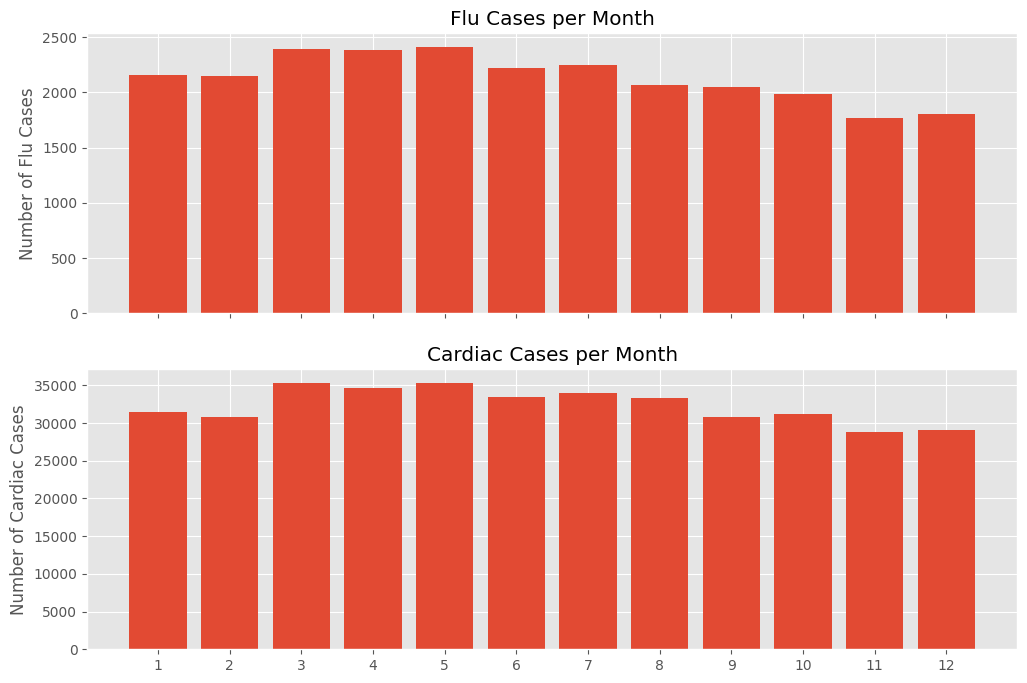

In [ ]:
fig, ax = plt.subplots(2, 1, figsize = (12, 8), sharex=True)

df_dict = {'flu': flu_df_deduped,
          'cardiac': cardiac_df_deduped,
           }

i = 0
for name, df in df_dict.items():

  month_order = df['condition_start_date_month'].value_counts().sort_index().reset_index()

  ax[i].bar(month_order['condition_start_date_month'], month_order['count'])
  ax[i].set_xticks(np.arange(1, 13, 1))
  ax[i].set_label("Month")
  ax[i].set_ylabel(f"Number of {name.title()} Cases")
  ax[i].set_title(f"{name.title()} Cases per Month")

  i += 1

plt.show()

In [ ]:
query = """
        SELECT COUNT(DISTINCT(`person_id`)) as `num_total_people`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.person`
        ;"""

unique_people_df = bq.run(query)
display(unique_people_df)

unique_people = unique_people_df['num_total_people'].iloc[0]

,num_total_people
0,2326856


In [ ]:
cardiac_df['person_id'].nunique()

### Conditional Probabilities

Irrespective of time or number of cases, how connected are flu diagnoses and cardiac problems?



In [ ]:
w_cardiac = cardiac_df['person_id'].nunique() / unique_people
w_flu = flu_df['person_id'].nunique() / unique_people
w_both = case_joined['person_id'].nunique() / unique_people
if_independent = w_cardiac * w_flu

display(w_cardiac)
display(w_flu)


print(f"""Assumming statistical independence, the ratio of people w both flu and cardiac cases:""")
print(if_independent)

display(w_both)

print(f"""
Ratio of actual vs expected: { w_both / if_independent}
""")

np.float64(0.12541128458314568)

np.float64(0.010784079461728616)

Assumming statistical independence, the ratio of people w both flu and cardiac cases:
0.0013524452583421039


np.float64(0.002714392295870479)


Ratio of actual vs expected: 2.0070256294128455



In [ ]:
### Check for diabetes, other variables

## Outer Joined - All Patients

In [ ]:
all_cases = flu_df.merge(cardiac_df,
                         how='outer',
                         on='person_id',
                         suffixes=('_flu', '_cardiac'))
all_cases